# Task #1: Tweet Emotions Classification

### Loading dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
data_path = '/content/drive/My Drive/datasets/tweet_emotions.csv'
df = pd.read_csv(data_path)
df.head()

,Id,Tweet,Label
0,145353048817012000,Thinks that @melbahughes had a great 50th birt...,surprise
1,144279638024257000,"Como una expresiÃ³n tan simple, una sola oraci...",sadness
2,140499585285111000,the moment when you get another follower and y...,joy
3,145207578270507000,Be the greatest dancer of your life! practice ...,joy
4,139502146390470000,eww.. my moms starting to make her annual rum ...,disgust


In [3]:
df.shape

(21051, 3)

### Number of instances in each class label

In [4]:
df['Label'].value_counts()

,count
Label,
joy,8240
surprise,3849
sadness,3830
fear,2816
anger,1555
disgust,761


### Preparing the data

Using tokenizer to convert each tweet into a sequence of word indices, then converting every sequence into a 0/1 vector (multi-hot encoding).

In [5]:
from tensorflow.keras.preprocessing.text import Tokenizer

num_words = 10000
tokenizer = Tokenizer(num_words=num_words)
tokenizer.fit_on_texts(df['Tweet'])
sequences = tokenizer.texts_to_sequences(df['Tweet'])
sequences[0]

[1668, 14, 93, 4, 128, 5906, 195, 247]

**Encoding the input data**

In [6]:
import numpy as np

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            if j < dimension:
                results[i, j] = 1.
    return results

x_data = vectorize_sequences(sequences, num_words)
x_data[0]

array([0., 0., 0., ..., 0., 0., 0.])

**Encoding the labels**

In [7]:
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_integers = label_encoder.fit_transform(df['Label'])
y_data = to_categorical(y_integers)
y_data[0]

array([0., 0., 0., 0., 0., 1.])

### Splitting data into 80% train and 20% test

In [8]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_data, y_data,
    test_size=0.2,
    stratify=y_integers,
    random_state=42
)

x_train.shape, x_test.shape

((16840, 10000), (4211, 10000))

**validation set**

In [9]:
x_val = x_train[:2000]
partial_x_train = x_train[2000:]
y_val = y_train[:2000]
partial_y_train = y_train[2000:]

### Building model

In [10]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(6, activation="softmax")
])
model.summary()
model.compile(optimizer="rmsprop",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Training model**

In [11]:
history = model.fit(partial_x_train, partial_y_train,
                    epochs=10,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.4041 - loss: 1.6321 - val_accuracy: 0.4630 - val_loss: 1.4819
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.5073 - loss: 1.3565 - val_accuracy: 0.5315 - val_loss: 1.3156
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5921 - loss: 1.1634 - val_accuracy: 0.5505 - val_loss: 1.2228
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.6470 - loss: 1.0171 - val_accuracy: 0.5640 - val_loss: 1.1778
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.6908 - loss: 0.8973 - val_accuracy: 0.5680 - val_loss: 1.1614
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.7322 - loss: 0.7980 - val_accuracy: 0.5770 - val_loss: 1.1543
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.7668 - loss: 0.7093 - val_accuracy: 0.5710 - val_loss: 1.1731
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.7962 - loss: 0.6321 - val_accuracy: 0.5795 - v

**Plotting training and validation loss**

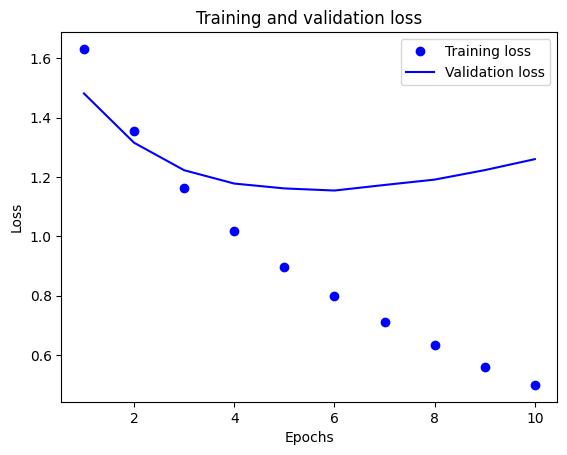

In [12]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Plotting training and validation accuracy**

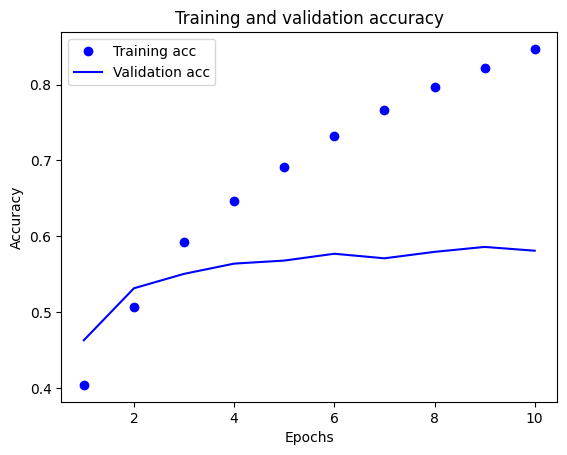

In [13]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]

plt.plot(epochs, acc, "bo", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Train and test accuracy

In [14]:
train_results = model.evaluate(x_train, y_train)
print(f"Training accuracy: {train_results[1]}")

527/527 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8496 - loss: 0.5188
Training accuracy: 0.8495843410491943


In [15]:
test_results = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_results[1]}")

132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5894 - loss: 1.2184
Test accuracy: 0.5894086956977844


### Question: Does accuracy vary from class to class label?

In [16]:
from sklearn.metrics import classification_report

predictions = model.predict(x_test)
y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

       anger       0.47      0.39      0.42       311
     disgust       0.38      0.20      0.26       152
        fear       0.58      0.57      0.58       563
         joy       0.68      0.74      0.71      1649
     sadness       0.51      0.49      0.50       766
    surprise       0.52      0.54      0.53       770

    accuracy                           0.59      4211
   macro avg       0.52      0.49      0.50      4211
weighted avg       0.58      0.59      0.58      4211



**Answer:**
Accuracy differs across classes mainly because joy has far more training examples ~8,240 than classes like disgust ~761, and emotions with similar wording (like anger/disgust or surprise/joy) are easy for the model to mix up.

### Adding two more layers of 32 neurons

In [17]:
model2 = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(6, activation="softmax")
])

model2.compile(optimizer="rmsprop",
               loss="categorical_crossentropy",
               metrics=["accuracy"])

history2 = model2.fit(partial_x_train, partial_y_train,
                      epochs=10,
                      batch_size=512,
                      validation_data=(x_val, y_val))

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.3711 - loss: 1.6238 - val_accuracy: 0.4190 - val_loss: 1.4765
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.4929 - loss: 1.3443 - val_accuracy: 0.5265 - val_loss: 1.3017
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.5988 - loss: 1.1313 - val_accuracy: 0.5545 - val_loss: 1.2168
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.6605 - loss: 0.9619 - val_accuracy: 0.5580 - val_loss: 1.1929
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.7132 - loss: 0.8201 - val_accuracy: 0.5545 - val_loss: 1.2120
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.7605 - loss: 0.7023 - val_accuracy: 0.5730 - val_loss: 1.2300
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.7987 - loss: 0.5967 - val_accuracy: 0.5395 - val_loss: 1.3383
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.8322 - loss: 0.5106 - val_accuracy: 0.5705 - v

In [18]:
train_results2 = model2.evaluate(x_train, y_train)
test_results2 = model2.evaluate(x_test, y_test)

print(f"Original model (2 hidden layers) -> train acc: {train_results[1]}, test acc: {test_results[1]}")
print(f"Deeper model (4 hidden layers)    -> train acc: {train_results2[1]}, test acc: {test_results2[1]}")

527/527 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8750 - loss: 0.4362
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5873 - loss: 1.5345
Original model (2 hidden layers) -> train acc: 0.8495843410491943, test acc: 0.5894086956977844
Deeper model (4 hidden layers)    -> train acc: 0.875, test acc: 0.5872714519500732


**Comments:**

Adding two more 32-neuron layers doesn't improve test accuracy and can even make it slightly worse, since the extra parameters just help the model overfit the training data faster without adding real value for a dataset this simple.